<span style="font-size: 20px;"> О датасете </span>

Bank Marketing Campaign Dataset (датасет маркетинговой кампании банка)
Представлены данные португальского банка, который проводил прямую маркетинговую кампанию по телефону. Банк звонил клиентам и предлагал им оформить срочный банковский вклад. Далее исследуем данные для того, чтобы понять какие факторы влияют на решение клиента оформить вклад.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

----------------------------------------------------------------------------------------------------

<span style="font-size: 20px;"> Чтение данных и приведение столбцов к snake_case </span>

In [3]:
bank_camp = pd.read_csv('Bank_Campaign.csv', sep=';')
bank_camp.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


----------------------------------------------------------------------------------------------------

<span style="font-size: 20px;">Описание признаков </span>

<span style="font-size: 13px;">

* age — возраст клиента
* job — профессия клиента
* marital — семейное положение
* education — уровень образования
* default — наличие просрочки по кредиту
* housing — наличие ипотечного кредита
* loan — наличие потребительского кредита
* contact — тип связи (мобильный или городской телефон)
* month — месяц звонка
* day_of_week — день недели звонка
* duration — длительность разговора в секундах
* campaign — количество контактов с клиентом в текущей кампании
* pdays — количество дней с момента предыдущего контакта (999 означает, что контактов не было)
* previous — количество контактов до текущей кампании
* poutcome — результат предыдущей маркетинговой кампании
* emp.var.rate — изменение уровня занятости
* cons.price.idx — индекс потребительских цен (инфляция)
* cons.conf.idx — индекс потребительского доверия
* euribor3m — 3-месячная ставка Euribor
* nr.employed — количество занятых
* subscribed — целевая переменная: согласился ли клиент на срочный вклад (yes/no) </span>

----------------------------------------------------------------------------------------------------

In [3]:
bank_camp.info()
bank_camp.shape

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

(41188, 21)

In [4]:
bank_camp.columns = bank_camp.columns.str.replace('.', '_')

----------------------------------------------------------------------------------------------------

<span style="font-size: 20px;">Подсчет unknown только для текстовых столбцов</span>

In [5]:
for col in bank_camp.select_dtypes(include=['str']).columns:
    count = (bank_camp[col] == 'unknown').sum()
    if count > 0:
        count = round((count*100/bank_camp.shape[0]), 2)
        print(f"{col}: {count}%")

job: 0.8%
marital: 0.19%
education: 4.2%
default: 20.87%
housing: 2.4%
loan: 2.4%


<span style="font-size: 15px;">default — 20.87% -> процент довольно высокий 
Возможно, банк не проверял кредитную историю у части клиентов или не задавал этот вопрос в некоторых звонках, или данные просто не были зафиксированы. Просто заменить unknown на no доволно рискованно, поэтому лучше оставить unknown как отдельную категорию.</span>

In [6]:
for col in bank_camp.select_dtypes(include=['string']).columns:
    print(f"{col}: {bank_camp[col].nunique()}")

job: 12
marital: 4
education: 8
default: 3
housing: 3
loan: 3
contact: 2
month: 10
day_of_week: 5
poutcome: 3
subscribed: 2


----------------------------------------------------------------------------------------------------

<span style="font-size: 20px;">Преобразование категориальных столбцов</span>

In [7]:
bank_camp['marital'] = bank_camp['marital'].astype('category')
bank_camp['default'] = bank_camp['default'].astype('category')
bank_camp['housing'] = bank_camp['housing'].astype('category')
bank_camp['loan'] = bank_camp['loan'].astype('category')
bank_camp['contact'] = bank_camp['contact'].astype('category')
bank_camp['poutcome'] = bank_camp['poutcome'].astype('category')
bank_camp['subscribed'] = bank_camp['subscribed'].astype('category')

In [8]:
bank_camp['day_of_week'].unique()

<StringArray>
['mon', 'tue', 'wed', 'thu', 'fri']
Length: 5, dtype: str

In [9]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
bank_camp['month'] = pd.Categorical(bank_camp['month'], categories=month_order, ordered=True)

dow_order = ['mon', 'tue', 'wed', 'thu', 'fri']
bank_camp['day_of_week'] = pd.Categorical(bank_camp['day_of_week'], categories=dow_order, ordered=True)

In [10]:
bank_camp.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             41188 non-null  int64   
 1   job             41188 non-null  str     
 2   marital         41188 non-null  category
 3   education       41188 non-null  str     
 4   default         41188 non-null  category
 5   housing         41188 non-null  category
 6   loan            41188 non-null  category
 7   contact         41188 non-null  category
 8   month           41188 non-null  category
 9   day_of_week     41188 non-null  category
 10  duration        41188 non-null  int64   
 11  campaign        41188 non-null  int64   
 12  pdays           41188 non-null  int64   
 13  previous        41188 non-null  int64   
 14  poutcome        41188 non-null  category
 15  emp_var_rate    41188 non-null  float64 
 16  cons_price_idx  41188 non-null  float64 
 17  cons_conf_idx   41188 n

В столбце job есть значения с точкой на конце, следует её убрать для чистоты данных

In [11]:
bank_camp['job'] = bank_camp['job'].str.rstrip('.')

In [12]:
bank_camp['job'].unique()

<StringArray>
[    'housemaid',      'services',         'admin',   'blue-collar',
    'technician',       'retired',    'management',    'unemployed',
 'self-employed',       'unknown',  'entrepreneur',       'student']
Length: 12, dtype: str

----------------------------------------------------------------------------------------------------

<span style="font-size: 20px;">Проверка на пропуски и их заполнение</span>

In [13]:
def missing(df, df_name):
    count = df.shape[0]
    missing_data = df.isnull().sum()
    missing_percent = (missing_data/count)*100
    missing_df = pd.DataFrame({
        'Количество пропусков': missing_data,
        'Процент пропусков': round(missing_percent, 2)
    })

    print(df_name, '\n')
    print(f'Всего строк: {count}\n')
    print(missing_df, '\n')
    print('Столбцы с пропущенными значениями:')
    print(missing_df[missing_df['Количество пропусков'] > 0]
          if len(missing_df[missing_df['Количество пропусков']>0])>0 else 0)

In [14]:
missing(bank_camp, 'bank_camp')

bank_camp 

Всего строк: 41188

                Количество пропусков  Процент пропусков
age                                0                0.0
job                                0                0.0
marital                            0                0.0
education                          0                0.0
default                            0                0.0
housing                            0                0.0
loan                               0                0.0
contact                            0                0.0
month                              0                0.0
day_of_week                        0                0.0
duration                           0                0.0
campaign                           0                0.0
pdays                              0                0.0
previous                           0                0.0
poutcome                           0                0.0
emp_var_rate                       0                0.0
cons_price_idx  

Заменим в столбце pdays значение 999 на соответствующее значение 0

In [15]:
bank_camp['pdays_clean'] = bank_camp['pdays'].replace(999, 0)

In [16]:
bank_camp[bank_camp['pdays_clean']==999]['pdays_clean'].count()

np.int64(0)

----------------------------------------------------------------------------------------------------

<span style="font-size: 20px;">Поиск и обработка дубликатов</span>

In [17]:
duplicates_count = bank_camp.duplicated().sum()
duplicates_count

np.int64(12)

In [18]:
duplicates_percent = round((duplicates_count / len(bank_camp)) * 100, 2)
duplicates_percent

np.float64(0.03)

Процент дубликатов составляет 0.03, что очень мало. В данном случае процент дубликатов является скорее всего ошибкой сбором данных или случайным повтором. Удалим их.

In [19]:
bank_camp = bank_camp.drop_duplicates()

In [20]:
bank_camp.shape[0]

41176

В датасете bank_camp неявные дубликаты могут означать, что одному клиенту звонили несколько раз,
и это возможно. 

----------------------------------------------------------------------------------------------------

<span style="font-size: 20px;">Анализ и обработка выбросов</span>

In [21]:
print('Описательная статистика для возраста:')
print(bank_camp['age'].describe())

Описательная статистика для возраста:
count    41176.00000
mean        40.02380
std         10.42068
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64


Проверим числовые столбцы такие, как age, duration campaign на наличие выбросов.

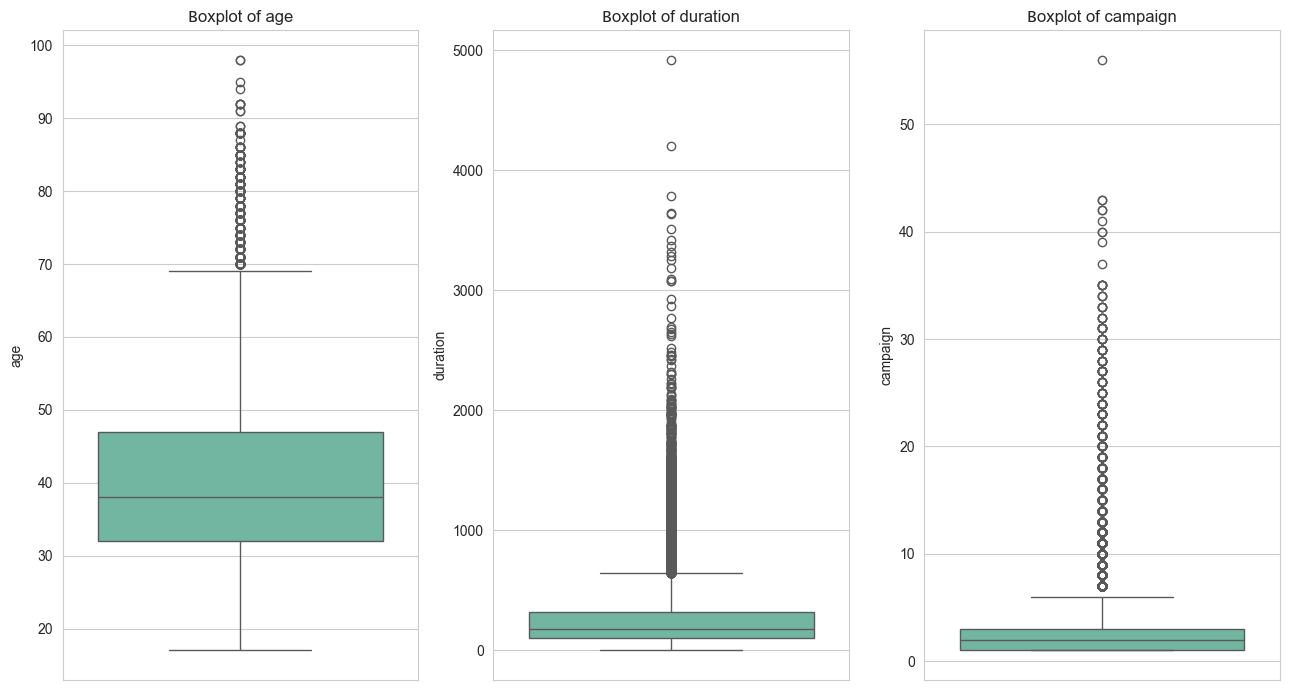

In [60]:
check_columns = ['age', 'duration', 'campaign']
fig, axes = plt.subplots(1, 3, figsize=(13, 7))
for i, col in enumerate(check_columns):
    sns.boxplot(data=bank_camp, y=col, ax= axes[i])
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()

In [22]:
def count_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_q = Q1 - 1.5 * IQR
    upper_q = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_q) | (df[column] > upper_q)]
    count = len(outliers)
    precent = round((count/len(df)) * 100, 2)

    return count, precent, lower_q, upper_q


In [23]:
count_outliers(bank_camp, 'age')

(468, 1.14, np.float64(9.5), np.float64(69.5))

Процент выбросов в признаке age меньше 2% и вполне уместен, поэтому можно оставить как есть.

In [24]:
count_outliers(bank_camp, 'duration')

(2963, 7.2, np.float64(-223.5), np.float64(644.5))

In [25]:
count_outliers(bank_camp, 'campaign')

(2406, 5.84, np.float64(-2.0), np.float64(6.0))

Построим гистограммы распределений для признаков duration и campaign

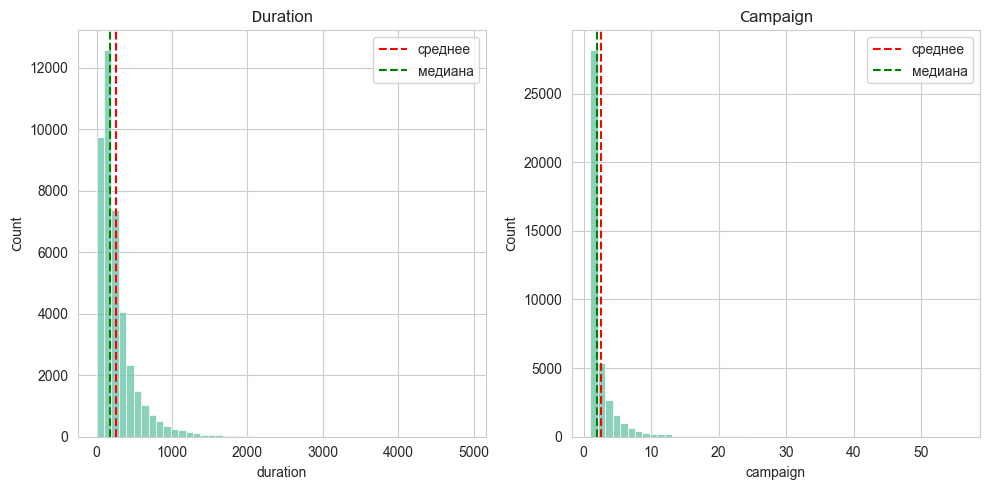

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(bank_camp['duration'], bins=50, ax=axes[0])
axes[0].set_title('Duration')
axes[0].axvline(bank_camp['duration'].mean(), color='red', linestyle='--', label='среднее')
axes[0].axvline(bank_camp['duration'].median(), color='green', linestyle='--', label='медиана')
plt.tight_layout()
axes[0].legend()


sns.histplot(bank_camp['campaign'], bins=50, ax=axes[1])
axes[1].set_title('Campaign')
axes[1].axvline(bank_camp['campaign'].mean(), color='red', linestyle='--', label='среднее')
axes[1].axvline(bank_camp['campaign'].median(), color='green', linestyle='--', label='медиана')
plt.tight_layout()
axes[1].legend();

Распределение двух признаков скошено вправо

In [26]:
#Логарифмирование колонки duration
bank_camp['duration_log'] = np.log1p(bank_camp['duration'])

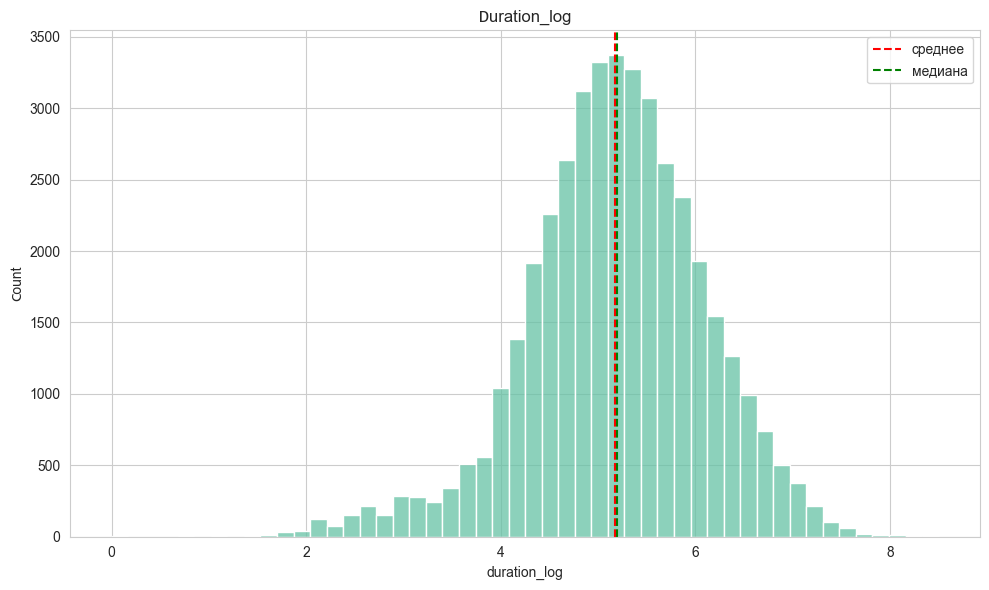

In [67]:
fig, axes = plt.subplots(figsize=(10, 6))
sns.histplot(bank_camp['duration_log'], bins=50)
axes.set_title('Duration_log')
axes.axvline(bank_camp['duration_log'].mean(), color='red', linestyle='--', label='среднее')
axes.axvline(bank_camp['duration_log'].median(), color='green', linestyle='--', label='медиана')
plt.tight_layout()
axes.legend();

Получили распределение ближе к нормальному, влияние выбросов уменьшено

Снова посмотрим на процент выбросов призанка campaign

In [27]:
count_outliers(bank_camp, 'campaign')

(2406, 5.84, np.float64(-2.0), np.float64(6.0))

Процент больше 5 и меньше 10, можно применить capping

In [28]:
upper_cap = bank_camp['campaign'].quantile(0.95)
bank_camp['campaign_capped'] = bank_camp['campaign'].clip(upper=upper_cap)

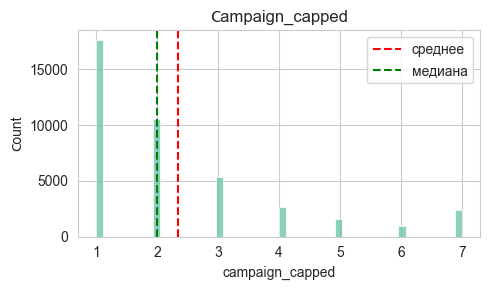

In [80]:
fig, axes = plt.subplots(figsize=(5,3))
sns.histplot(bank_camp['campaign_capped'])
axes.set_title('Campaign_capped')
axes.axvline(bank_camp['campaign_capped'].mean(), color='red', linestyle='--', label='среднее')
axes.axvline(bank_camp['campaign_capped'].median(), color='green', linestyle='--', label='медиана')
plt.tight_layout()
axes.legend();

In [29]:
bank_camp['campaign_capped'].describe()

count    41176.000000
mean         2.333908
std          1.701373
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          7.000000
Name: campaign_capped, dtype: float64

In [30]:
bank_camp['campaign'].describe()

count    41176.000000
mean         2.567879
std          2.770318
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64

Это уменьшило влияние выбросов на среднее значение и разброс признака, хоть и не слишком сильно

----------------------------------------------------------------------------------------------------

<span style="font-size: 20px;">Графический анализ целевой переменной</span>

In [31]:
sns.set_style('whitegrid')
sns.set_palette('Set2')

Преобразуем целевую переменную в числовой формат для удобства

In [32]:
bank_camp['subscribed_num'] = (bank_camp['subscribed'] == 'yes').astype(int)

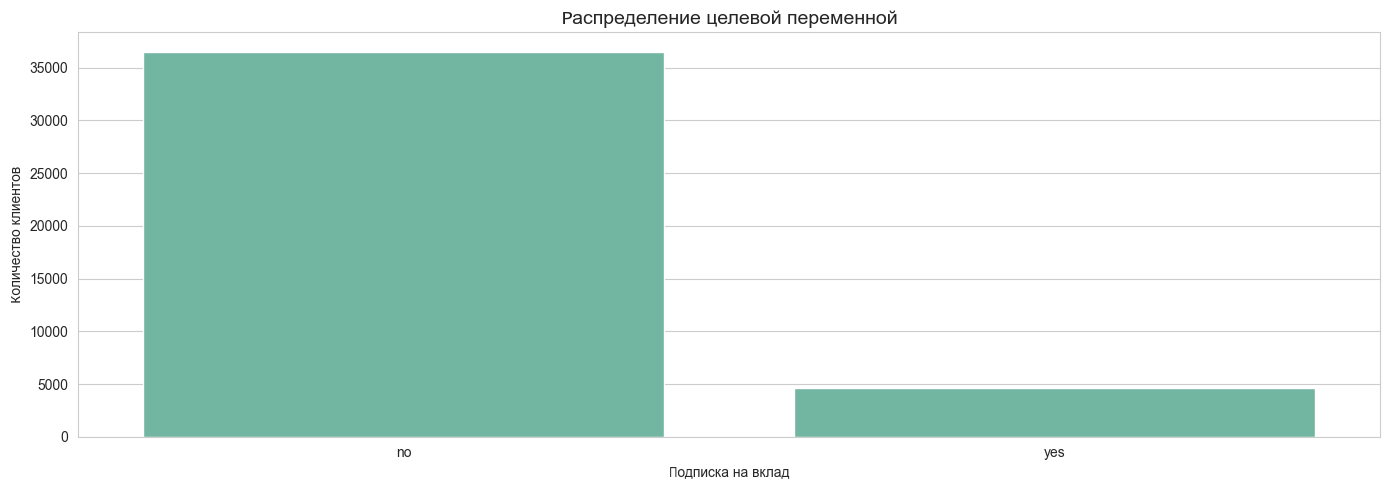

Общая конверсия: 11.27%
Подписалось: 4639 клиентов
Не подписалось: 36537 клиентов


In [75]:
fig, axes = plt.subplots(figsize=(14, 5))

sns.countplot(data=bank_camp, x='subscribed', legend=False)
axes.set_title('Распределение целевой переменной', fontsize=14)
axes.set_xlabel('Подписка на вклад')
axes.set_ylabel('Количество клиентов')

plt.tight_layout()
plt.show()

conversion_rate = bank_camp['subscribed_num'].mean() * 100
print(f"Общая конверсия: {conversion_rate:.2f}%")
print(f"Подписалось: {bank_camp['subscribed_num'].sum():} клиентов")
print(f"Не подписалось: {(len(bank_camp) - bank_camp['subscribed_num'].sum()):} клиентов");

Распределение числовых признаков

In [76]:
bank_camp.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,subscribed,pdays_clean,duration_log,campaign_capped,subscribed_num
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,no,0,5.568345,1,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,no,0,5.010635,1,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,no,0,5.424950,1,0
3,40,admin,married,basic.6y,no,no,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,no,0,5.023881,1,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,no,0,5.730100,1,0


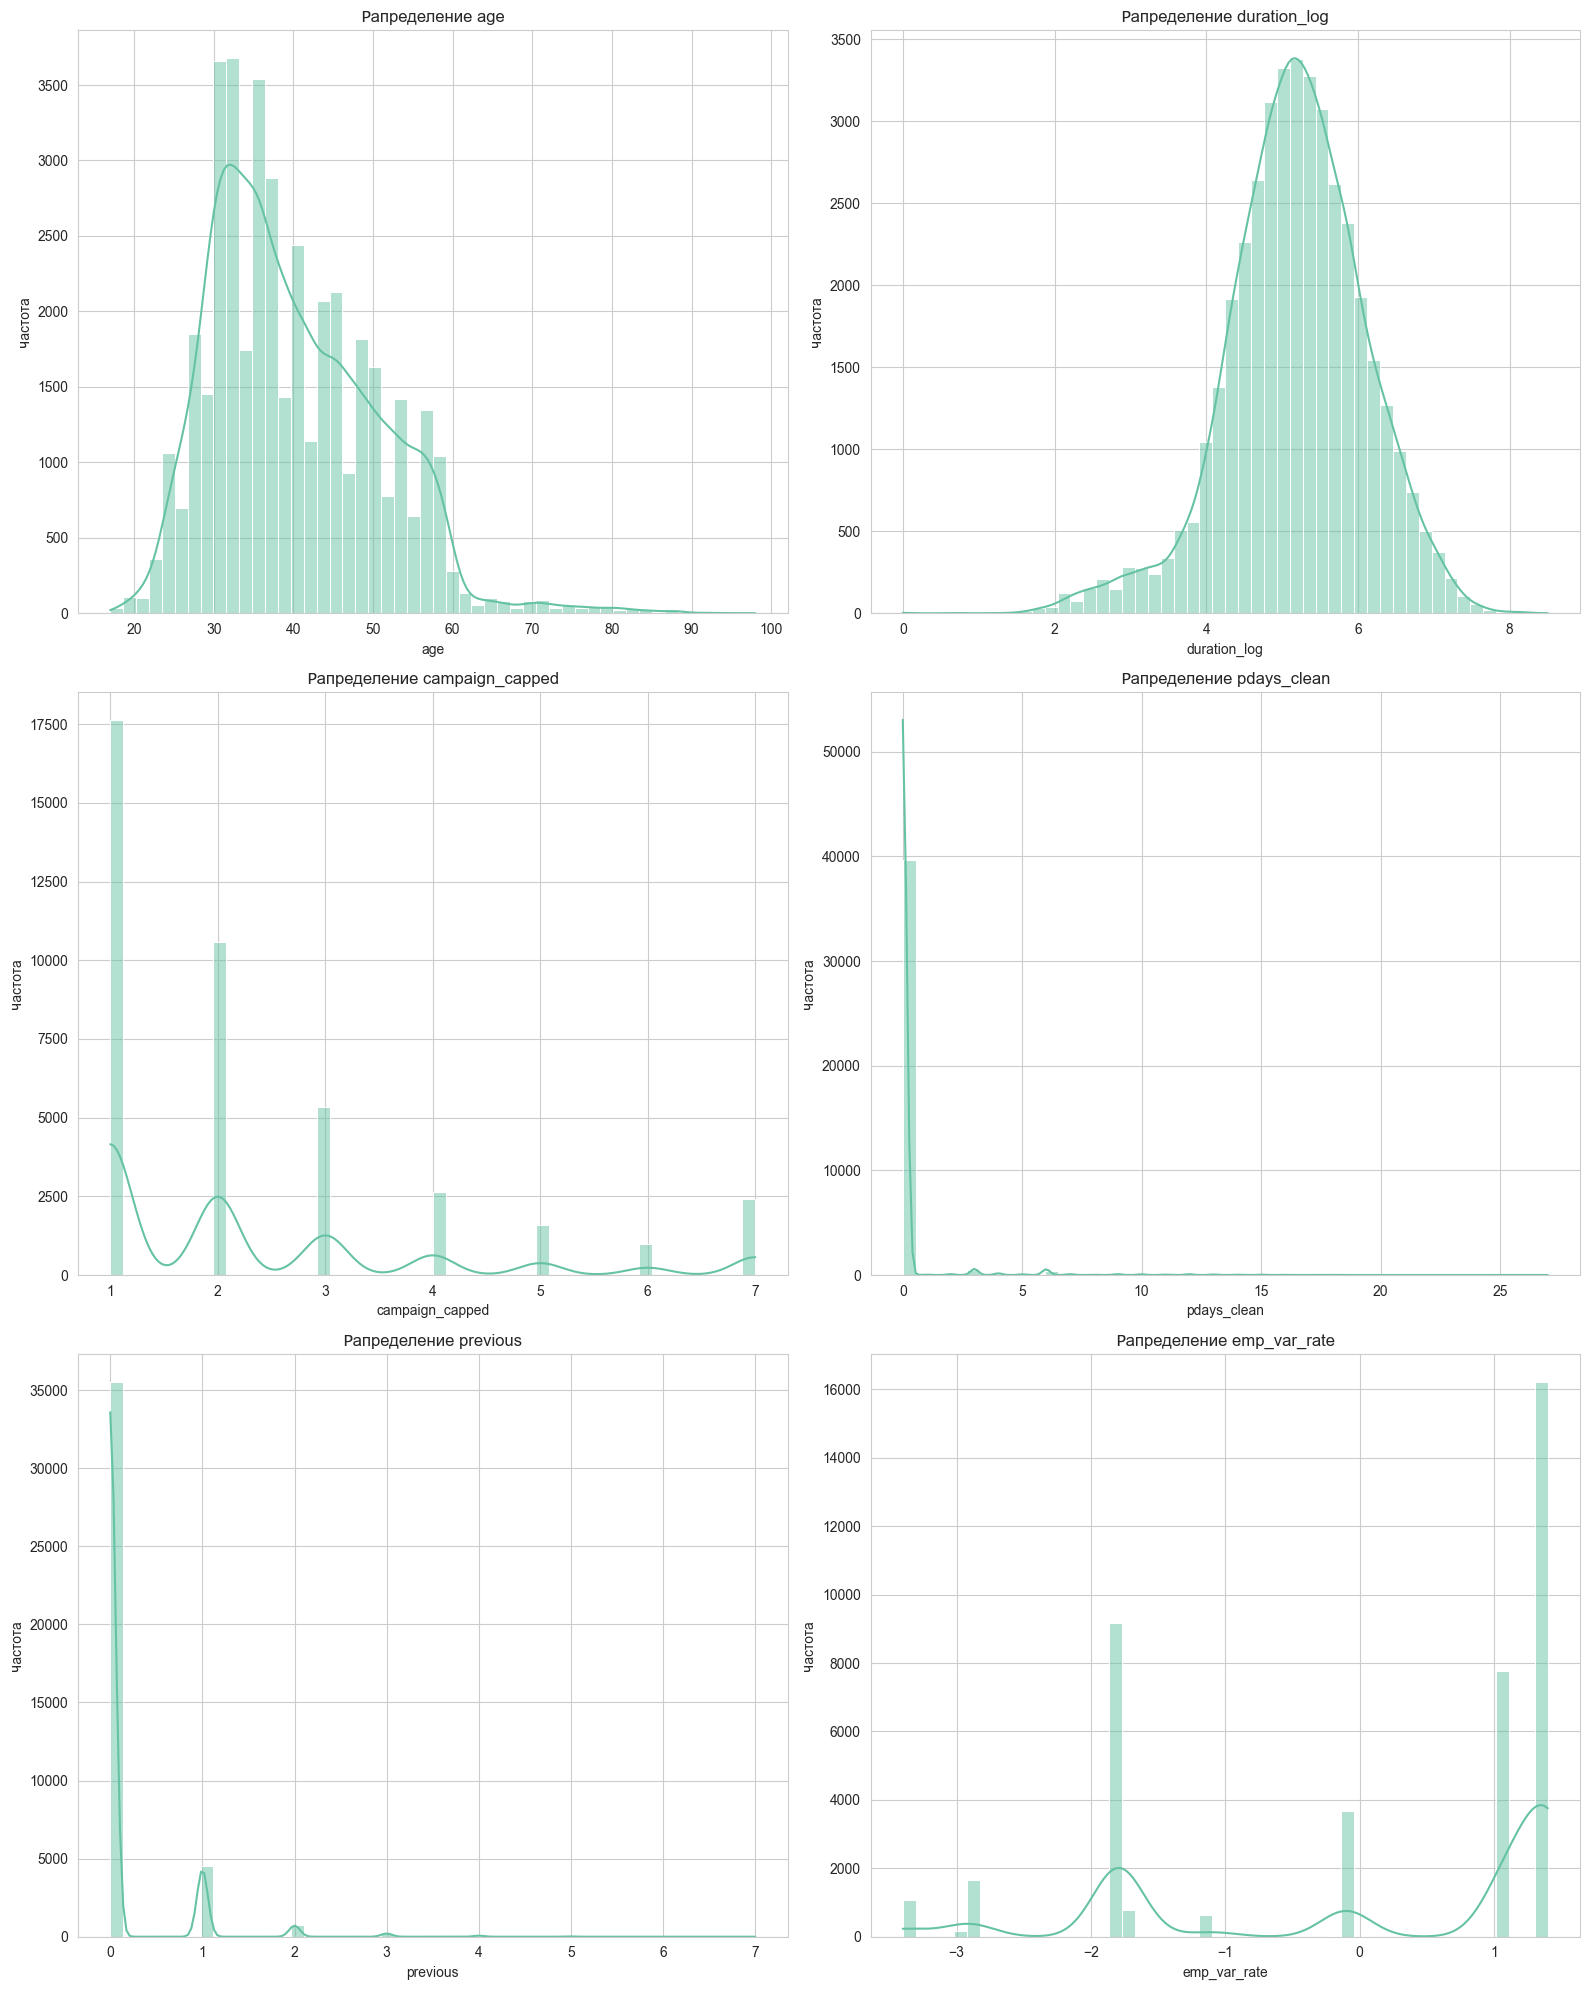

In [77]:
numeric_columns = ['age', 'duration_log', 'campaign_capped', 'pdays_clean', 'previous', 
                'emp_var_rate']
fig, axes = plt.subplots(3, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.histplot(data=bank_camp, x=col, kde=True,ax=axes[i], bins=50)
    axes[i].set_title(f'Рапределение {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

plt.tight_layout()


Вывод по полученным гистограммам:
* age — распределение возраста имеет асимметрию, большинство клиентов находятся в диапазоне 25–40 лет, пожилых клиентов значительно меньше, молодых клиентов до 25 лет также немного, что говорит о том, что основная аудитория банка — люди среднего возраста

* duration_log — после логарифмирования распределение длительности разговора стало близким к нормальному, пик приходится на значения 4–6, что соответствует 50–150 секундам разговора, правый хвост распределения указывает на наличие длительных разговоров, которые встречаются редко

* campaign_capped — распределение резко убывающее, подавляющее большинство клиентов получили 1 звонок, затем количество резко падает до 2 звонков и далее снижается, клиенты с 5 и более звонками составляют крайне малую долю, что говорит о том, что банк не склонен многократно названивать одному клиенту

* pdays_clean — наблюдается огромный пик на значении 0, что соответствует клиентам, у которых не было предыдущих контактов, остальные значения распределены относительно равномерно в диапазоне от 1 до 800 дней, что указывает на то, что большинство клиентов участвуют в кампании впервые

* previous — распределение сильно скошено влево, подавляющее большинство клиентов имеют значение 0, то есть не имели контактов до текущей кампании, клиенты с 1–2 предыдущими контактами встречаются значительно реже, а клиенты с 3 и более предыдущими контактами единичны

* emp_var_rate — распределение имеет несколько пиков, что отражает изменение экономической ситуации в разные периоды кампании

Построим boxplots, которые позволяют сравнить распределение каждого числового признака между двумя группами: подписавшимися (subscribed = yes) и неподписавшимися 

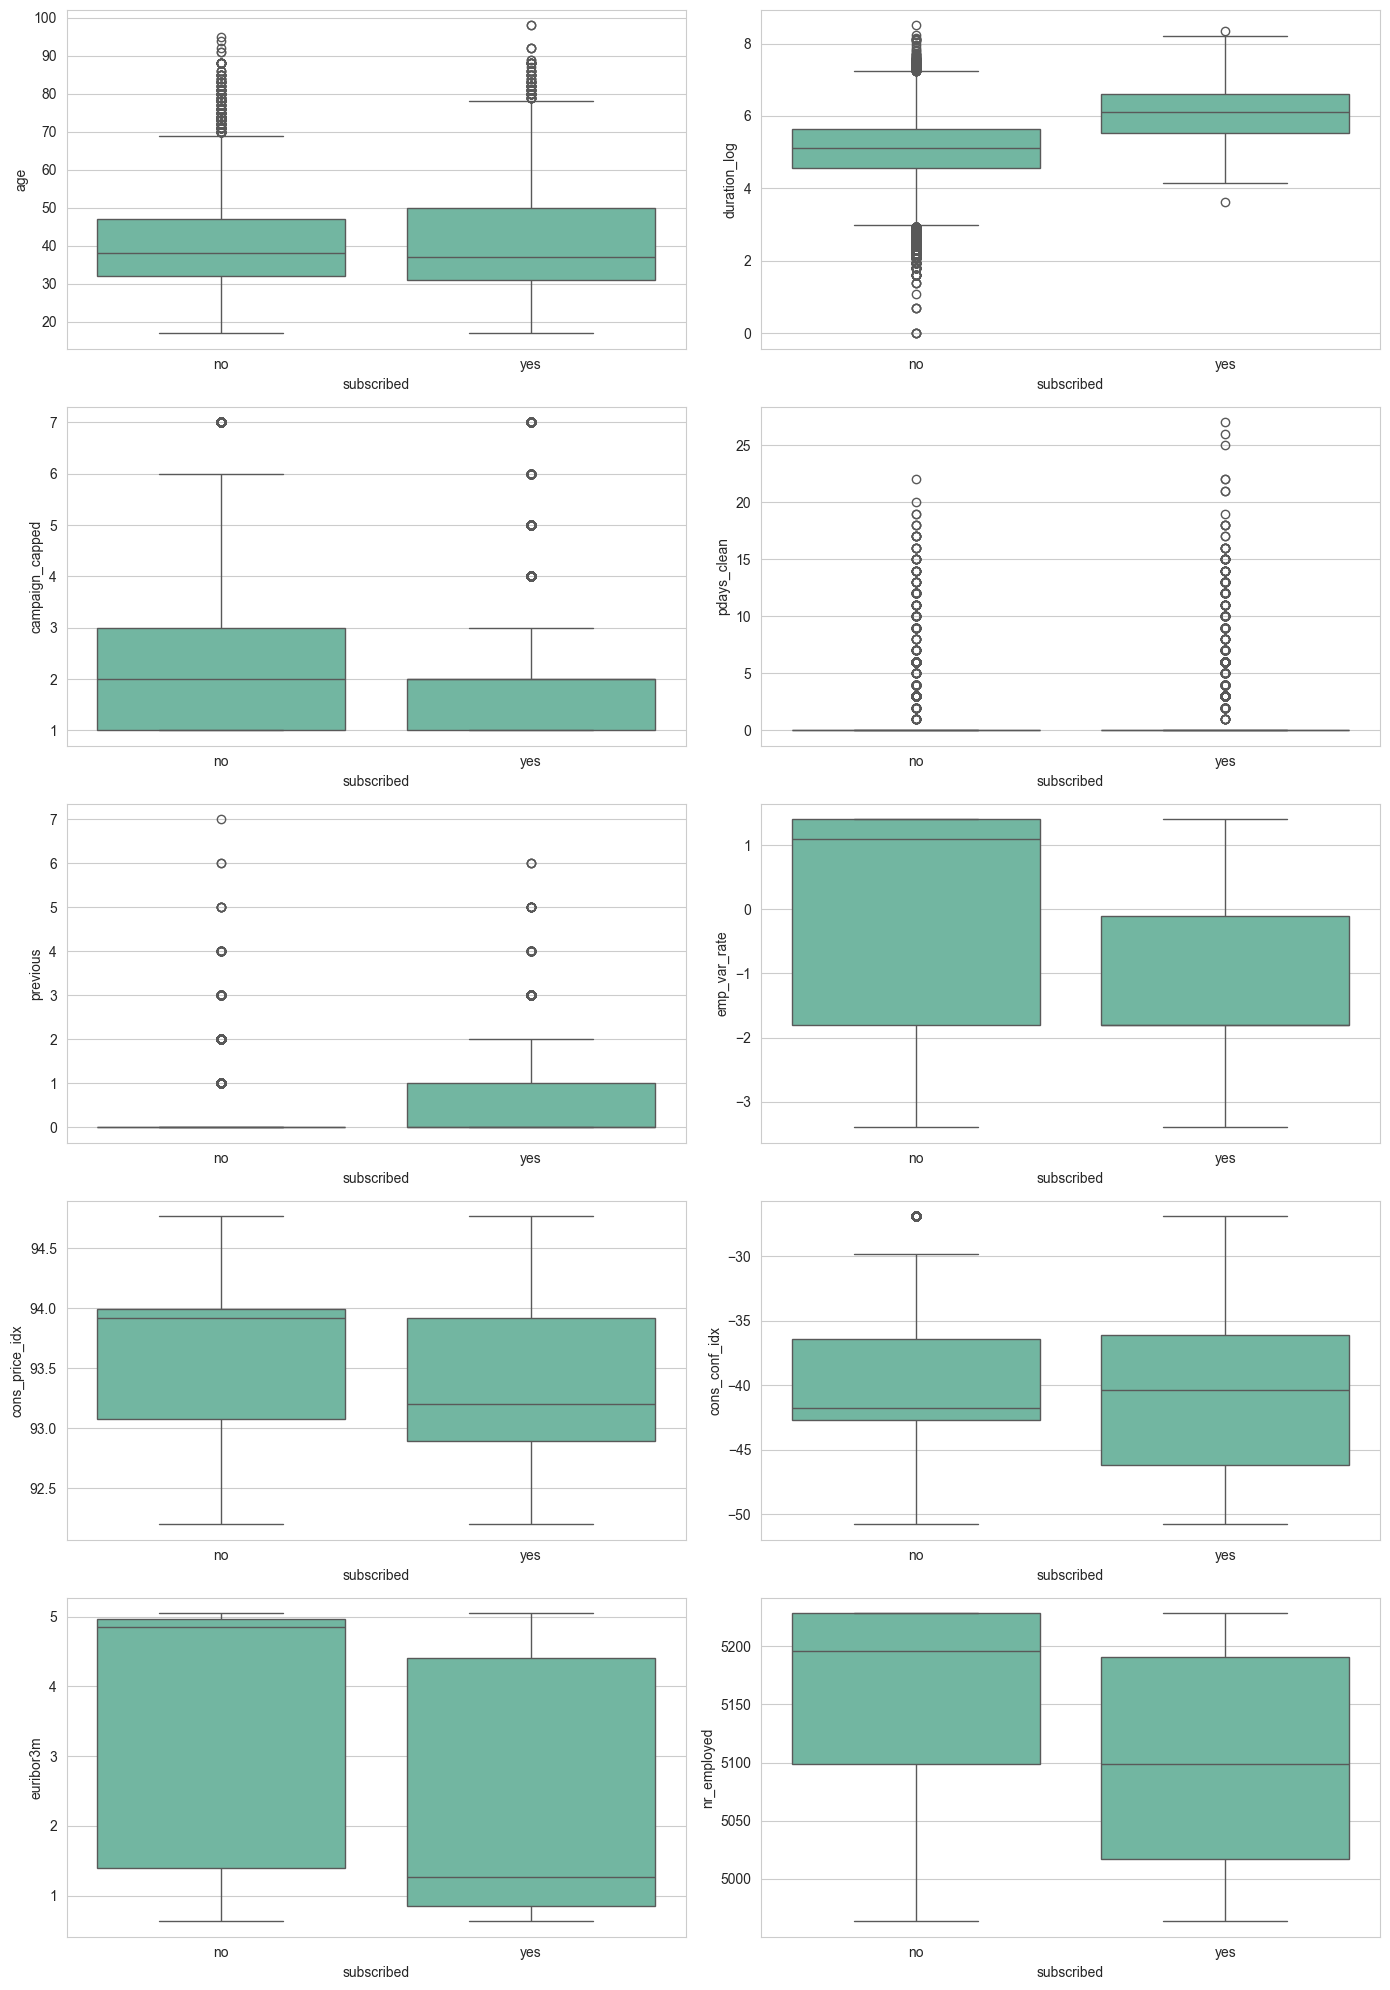

In [78]:
numeric_columns = ['age', 'duration_log', 'campaign_capped', 'pdays_clean', 'previous', 
                'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 
                'euribor3m', 'nr_employed']


fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(data=bank_camp, x='subscribed', y=col, ax=axes[i])
    #axes[i].set_title(f'{col} по группам подписки')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Выводы по графикам:
* age — медиана возраста у подписавшихся ниже, чем у неподписавшихся, то есть более молодые клиенты подписываются чаще, разброс значений схож, выбросы присутствуют в обеих группах.
* duration_log — логарифмированная длительность разговора у подписавшихся значительно выше, ящик смещен вверх, что подтверждает сильную связь между длительностью разговора и вероятностью подписки
* campaign_capped — у подписавшихся медиана количества звонков ниже (1–2), у неподписавшихся выше (2–3), что говорит о том, что большое количество звонков снижает вероятность успеха
* previous — у подписавшихся медиана количества предыдущих контактов чуть выше, но в целом обе группы имеют распределение с сильным перекосом в сторону нуля
* emp_var_rate — изменение занятости у подписавшихся имеет более низкие значения (больше отрицательных), что соответствует периоду кризиса, когда люди чаще вкладывали деньги

----------------------------------------------------------------------------------------------------

<span style="font-size: 20px;">Анализ категориальных признаков</span>

In [33]:
categorical_columns = ['job', 'marital', 'education', 'default', 
                    'housing', 'loan', 'contact', 'month', 
                    'day_of_week', 'poutcome']

Построение barplot с конверсией

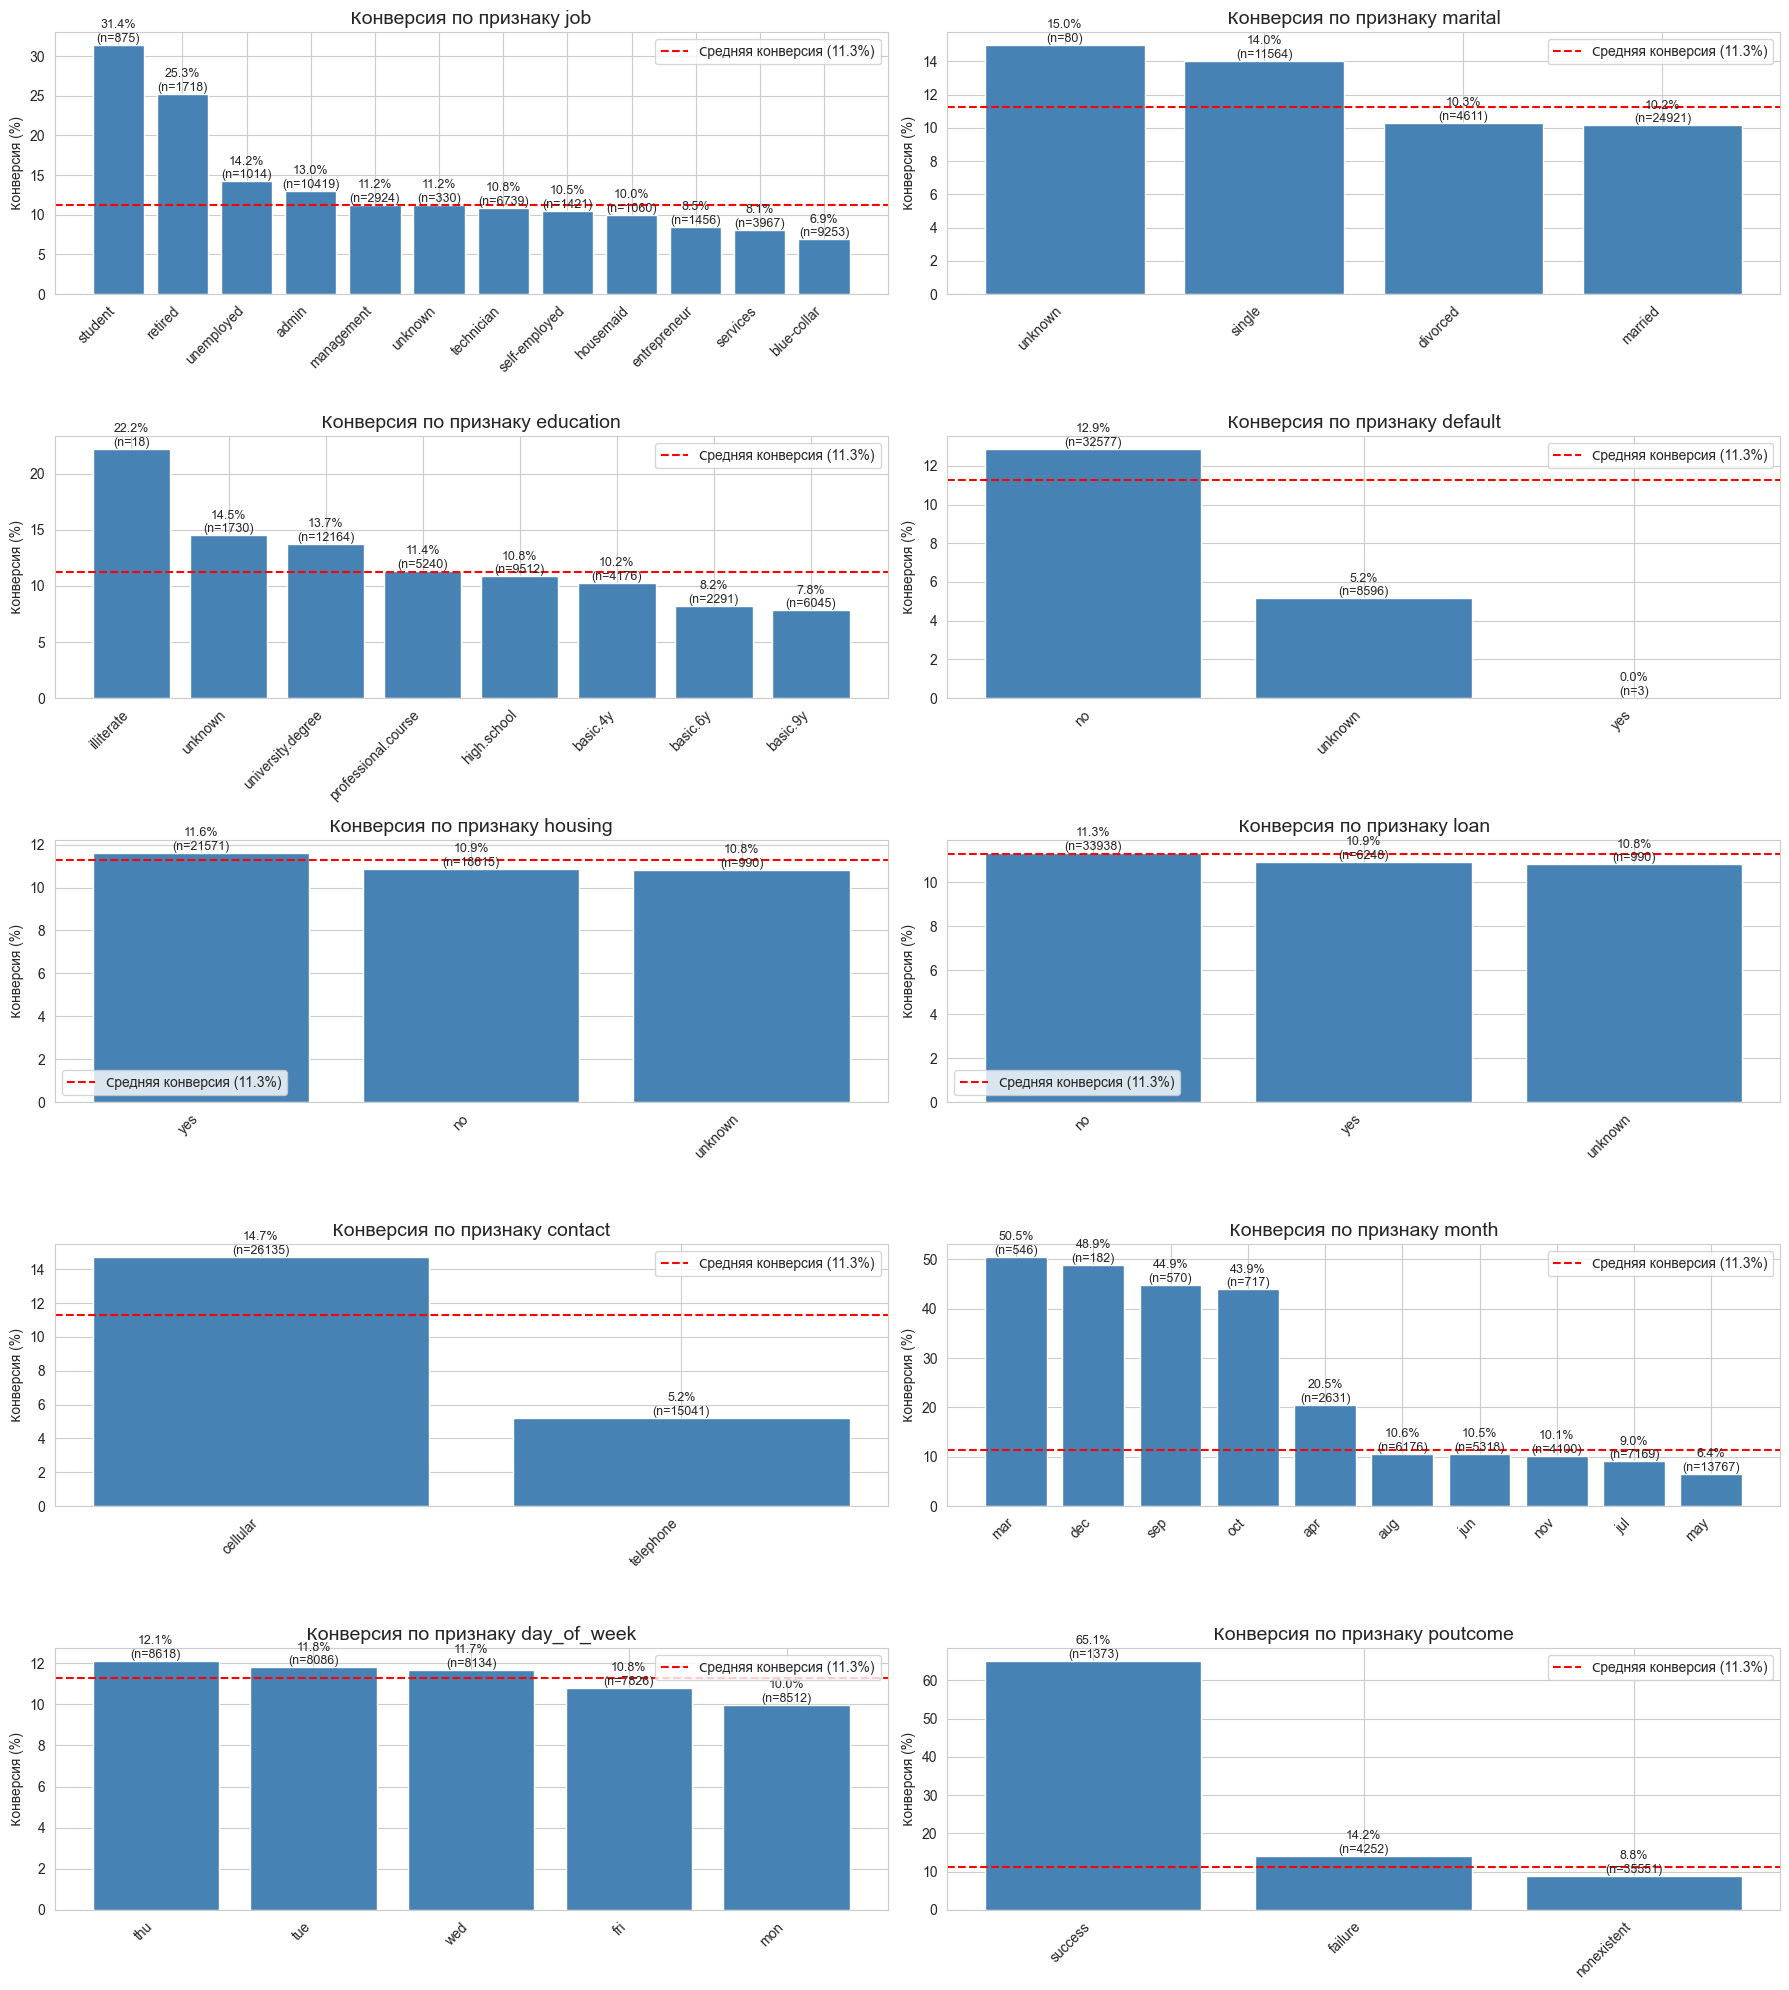

In [86]:

def plot_conversion_by_category(df, col, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
    
    
    conversion = df.groupby(col)['subscribed_num'].agg(['mean', 'count']).reset_index()
    conversion.columns = [col, 'conversion_rate', 'count']
    conversion = conversion.sort_values('conversion_rate', ascending=False)
    
    
    bars = ax.bar(range(len(conversion)), conversion['conversion_rate'] * 100, color='steelblue')
    ax.set_xticks(range(len(conversion)))
    ax.set_xticklabels(conversion[col], rotation=45, ha='right')
    ax.set_ylabel('Конверсия (%)')
    ax.set_title(f'Конверсия по признаку {col}', fontsize=14)
    ax.axhline(y=conversion_rate, color='red', linestyle='--', label=f'Средняя конверсия ({conversion_rate:.1f}%)')
    ax.legend()
    
   
    for i, (bar, row) in enumerate(zip(bars, conversion.iterrows())):
        ax.annotate(f"{row[1]['conversion_rate']*100:.1f}%\n(n={row[1]['count']})",
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)
    
    return ax


fig, axes = plt.subplots(5, 2, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    plot_conversion_by_category(bank_camp, col, ax=axes[i])

plt.tight_layout()
plt.show()

Вывод по графикам:
* job — самая высокая конверсия наблюдается у студентов и пенсионеров, что объясняется их большей склонностью к сбережениям и наличием свободного времени для общения с банком
* marital — unknown клиенты (клиенты, которые не указали свое семейное положение) показывают наиболее высокую конверсию, за ними следуют одинокие, а женатые и замужние демонстрируют результат ниже среднего
* education — клиенты с высшим образованием (tertiary) имеют самую высокую конверсию, что коррелирует с их финансовой грамотностью и более высоким уровнем дохода скорее всего
* default — как и ожидалось, клиенты с просрочкой по кредиту практически никогда не подписываются на новый вклад, их конверсия близка к нулю, тогда как клиенты без просрочек демонстрируют конверсию немного выше среднего значения
* housing — наличие ипотеки незначительно повышает конверсию, но разница не критична
* loan — наличие потребительского кредита значительно снижает конверсию, что логично, так как такие клиенты имеют высокую долговую нагрузку и меньше свободных средств для накоплений.
* contact — мобильная связь (cellular) дает конверсию почти в 2 раза выше, чем городской телефон (это объясняется тем, что мобильный телефон всегда под рукой, клиенты более доступны и могут разговаривать в комфортной обстановке)
* poutcome — самый сильный предиктор: клиенты с предыдущим успешным опытом подписываются в 5–6 раз чаще среднего, а клиенты с предыдущей неудачей демонстрируют минимальную конверсию, а клиенты без предыдущих контактов — на уровне средней
* month — на графике видно, что конверсия выше среднего в месяцах: март (mar), сентябрь (sep), октябрь (oct) и декабрь (dec). Самые низкие показатели конверсии наблюдаются в мае (may), июне (jun), июле (jul) и августе (aug), что противоречит распространенному представлению о летнем пике. Возможно, это связано с особенностями данной маркетинговой кампании или экономической ситуацией в конкретные периоды
* day_of_week — оптимальные дни для обзвона — вторник, среда и четверг, понедельник и пятницу же лучше исключить из активных кампаний или использовать для менее важных контактов

----------------------------------------------------------------------------------------------------

<span style="font-size: 20px;">Корреляционный анализ</span>

In [36]:
numeric_columns = ['age', 'duration_log', 'campaign_capped', 'pdays_clean', 'previous', 
                'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 
                'euribor3m', 'nr_employed', 'subscribed_num']

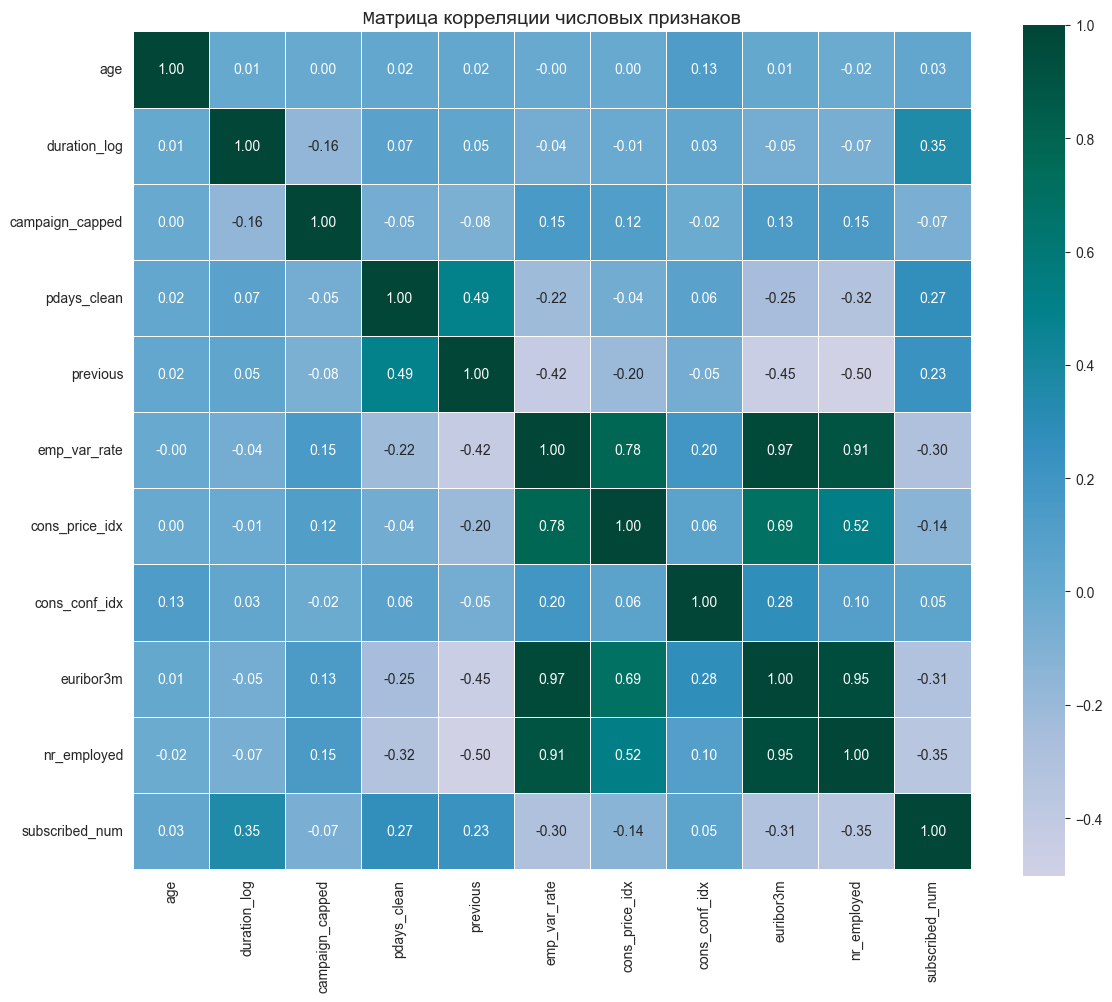

In [37]:
plt.figure(figsize=(12, 10))
corr_matrix = bank_camp[numeric_columns].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='PuBuGn', center=0, 
            square=True, linewidths=0.5)
plt.title('Матрица корреляции числовых признаков', fontsize=14)
plt.tight_layout()
plt.show()

Вывод по матрице корреляции:

* emp_var_rate и euribor3m (0.97) — очень сильная положительная связь. Это ожидаемо, так как в период кризиса (2008–2010) ставка Euribor падала одновременно с ростом безработицы

* nr_employed и euribor3m (0.95) — также очень сильная связь, так как количество занятых тесно связано с экономической ситуацией и ставкой Euribor

* nr_employed и emp_var_rate (0.91) — подтверждает ту же закономерность: изменение занятости и общее количество занятых сильно коррелируют

* Положительная корреляция 0.69 означает, что индекс потребительских цен (cons_price_idx) и ставка Euribor двигаются в одном направлении, так как центральные банки повышают ставки именно для того, чтобы сдерживать растущую инфляцию

* Положительная корреляция 0.78 означает, что индекс потребительских цен (cons_price_idx) и изменение уровня занятости двигаются в одном направлении

-> Все макроэкономические признаки (euribor3m, emp_var_rate, nr_employed, cons_price_idx) имеют сильную положительную корреляцию между собой (0.69–0.95), что указывает на их синхронное движение в рамках единого экономического цикла во время проведения кампании.

-----------------------------------------------

* euribor3m и subscribed_num (-0.31) — умеренная отрицательная корреляция. Чем ниже ставка Euribor, тем выше вероятность подписки

* duration_log и subscribed_num (0.35) — умеренная положительная корреляция. Длительные разговоры связаны с более высокой вероятностью подписки

* nr_employed и subscribed_num (-0.35) — умеренная отрицательная корреляция, в периоды с меньшим количеством занятых (кризис) конверсия выше (падение занятости становится триггером для консервативного финансового поведения, что парадоксальным образом повышает спрос на банковские депозиты)

* emp_var_rate и subscribed_num (-0.30) — аналогично, чем хуже ситуация с занятостью, тем выше конверсия

-----------------------------------------------
* age (0.06) — практически нет линейной связи с подпиской, возраст важен, но его влияние не линейное

* campaign_capped (-0.07) — очень слабая отрицательная связь (большое количество звонков немного снижает вероятность подписки)

* pdays_clean (0.07) — умеренная положительная связь (наличие предыдущих контактов (значения >0) умеренно повышает вероятность подписки на вклад)

* previous (0.09) — умеренная положительная корреляция также означает, что количество предыдущих контактов умеренно повышает вероятность подписки на вклад

* cons_conf_idx (0.05) — практически нет связи с подпиской

* cons_price_idx (-0.14) — слабая отрицательная связь, в периоды более высокой инфляции клиенты чуть реже открывают вклады. Однако это влияние значительно слабее, чем у euribor3m (-0.31), который остается самым сильным макроэкономическим предиктором

-----------------------------------------------------------------------------------------------------------------

In [39]:
# Сохранение обработанного датафрейма
bank_camp.to_csv('bank_camp_processed.csv', index=False)

-----------------------------------------------------------------------------------------------------------------

<span style="font-size: 20px;">Гипотезы</span>

* Гипотеза 1: Мобильная связь эффективнее городской 
* Гипотеза 2: Клиенты с предыдущим успехом кампании легче соглашаются на следующий
* Гипотеза 3: Чем больше звонков, тем ниже вероятность подписки

In [58]:
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest

In [59]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [60]:
# Функции для анализа

# Проверка нормальности распределения
def check_normality(data_a, data_b, metric_name):
    sample_a = data_a.sample(min(5000, len(data_a))) if len(data_a) > 5000 else data_a
    sample_b = data_b.sample(min(5000, len(data_b))) if len(data_b) > 5000 else data_b

    _, p_value_a = stats.shapiro(sample_a)
    _, p_value_b = stats.shapiro(sample_b)

    print(f"\nПроверка нормальности для '{metric_name}':")

    print(f"  Группа A: p-value = {p_value_a:.4f} {'(нормальное)' if p_value_a > 0.05 else '(не нормальное)'}")
    print(f"  Группа B: p-value = {p_value_b:.4f} {'(нормальное)' if p_value_b > 0.05 else '(не нормальное)'}")

    return p_value_a > 0.05 and p_value_b > 0.05


# Расчет доверительного интервала
def calculate_confidence_interval(data, confidence=0.95):
    mean = np.mean(data)
    sem = stats.sem(data)
    ci = stats.t.interval(confidence, len(data) - 1, loc=mean, scale=sem)
    return mean, ci


# Визуализация сравнения групп
def plot_comparison(data_a, data_b, metric_name, unit="", show_distribution=True):
    fig, axes = plt.subplots(1, 2 if show_distribution else 1, 
                           figsize=(14, 6) if show_distribution else (7, 6))
    
    if show_distribution:
        # Boxplot
        ax1 = axes[0]
        data_to_plot = [data_a.dropna(), data_b.dropna()]
        bp = ax1.boxplot(data_to_plot, labels=['Группа A', 'Группа B'], 
                        patch_artist=True)
        
        colors = ['lightblue', 'lightcoral']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
        
        ax1.set_title(f'Распределение {metric_name}', fontsize=14, fontweight='bold')
        ax1.set_ylabel(f'{metric_name} ({unit})' if unit else metric_name)
        ax1.grid(True, alpha=0.3)
        ax2 = axes[1]
    else:
        ax2 = axes
    
    # Barplot со средними и доверительными интервалами
    mean_a, ci_a = calculate_confidence_interval(data_a)
    mean_b, ci_b = calculate_confidence_interval(data_b)
    
    groups = ['Группа A', 'Группа B']
    means = [mean_a, mean_b]
    ci_lower = [mean_a - ci_a[0], mean_b - ci_b[0]]
    ci_upper = [ci_a[1] - mean_a, ci_b[1] - mean_b]
    
    bars = ax2.bar(groups, means, yerr=[ci_lower, ci_upper], 
                   capsize=10, color=['lightblue', 'lightcoral'], 
                   edgecolor='black', linewidth=1.5)
    
    for bar, mean_val in zip(bars, means):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{mean_val:.3f}', ha='center', va='bottom', fontweight='bold')
    
    ax2.set_title(f'Сравнение средних значений {metric_name}', fontsize=14, fontweight='bold')
    ax2.set_ylabel(f'Среднее значение ({unit})' if unit else 'Среднее значение')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return mean_a, mean_b, ci_a, ci_b


<span style="font-size: 20px;">Проверка гипотез</span>

-----------------------------------------------------------------------------------------------------------------

Гипотеза 1: Мобильная связь эффективнее городской 


ГИПОТЕЗА 1: Мобильная связь (cellular) дает более высокую конверсию
H₀: Конверсия cellular = конверсии telephone
H₁: Конверсия cellular > конверсии telephone

Размер группы A (telephone): 15041 клиентов
Размер группы B (cellular): 26135 клиентов

Проверка нормальности для 'длительность разговора':
  Группа A: p-value = 0.0000 (не нормальное)
  Группа B: p-value = 0.0000 (не нормальное)

Конверсия telephone: 5.23%
Конверсия cellular: 14.74%

Z-тест для пропорций:
   Z-статистика: 29.3774
   p-value: 0.000000

РЕЗУЛЬТАТ: p-value (0.000000) < 0.05 => Различие СТАТИСТИЧЕСКИ ЗНАЧИМО
   ВЫВОД: Конверсия в группе cellular статистически значимо ВЫШЕ, чем в telephone


C:\Users\Наиля\AppData\Local\Temp\ipykernel_15060\3330776982.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data_to_plot, labels=['Группа A', 'Группа B'],


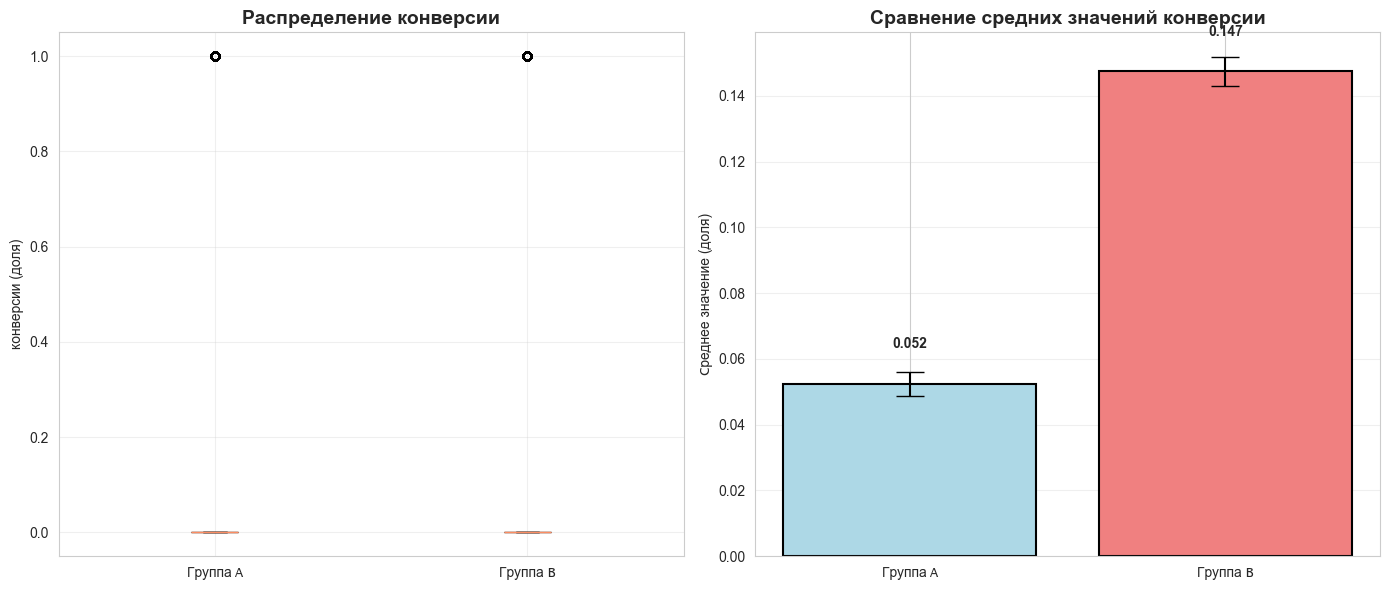


Дополнительная метрика: длительность разговора


C:\Users\Наиля\AppData\Local\Temp\ipykernel_15060\3330776982.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data_to_plot, labels=['Группа A', 'Группа B'],


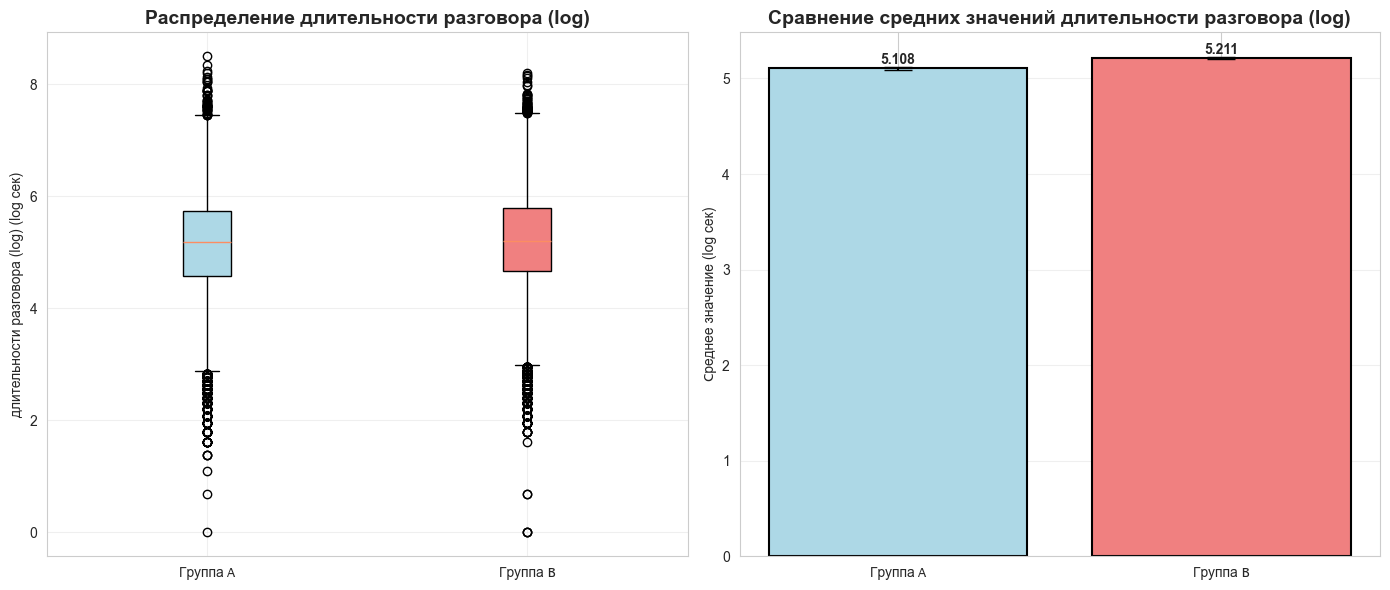

In [61]:
print("\n" + "=" * 60)
print("ГИПОТЕЗА 1: Мобильная связь (cellular) дает более высокую конверсию")
print("H₀: Конверсия cellular = конверсии telephone")
print("H₁: Конверсия cellular > конверсии telephone")
print("=" * 60)

# Подготовка данных
group_a = bank_camp[bank_camp['contact'] == 'telephone']  # контрольная группа
group_b = bank_camp[bank_camp['contact'] == 'cellular']   # тестовая группа

print(f"\nРазмер группы A (telephone): {len(group_a)} клиентов")
print(f"Размер группы B (cellular): {len(group_b)} клиентов")

# Проверка нормальности для duration (если нужно)
is_normal = check_normality(group_a['duration_log'].dropna(), 
                            group_b['duration_log'].dropna(), 
                            'длительность разговора')

# Z-тест для конверсии (пропорций)
success_a = group_a['subscribed_num'].sum()
success_b = group_b['subscribed_num'].sum()
n_a = len(group_a)
n_b = len(group_b)

conv_a = success_a / n_a * 100
conv_b = success_b / n_b * 100

print(f"\nКонверсия telephone: {conv_a:.2f}%")
print(f"Конверсия cellular: {conv_b:.2f}%")

# Z-тест (alternative='larger' - проверяем, что B > A)
count = np.array([success_b, success_a])
nobs = np.array([n_b, n_a])
z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print(f"\nZ-тест для пропорций:")
print(f"   Z-статистика: {z_stat:.4f}")
print(f"   p-value: {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nРЕЗУЛЬТАТ: p-value ({p_value:.6f}) < {alpha} => Различие СТАТИСТИЧЕСКИ ЗНАЧИМО")
    print(f"   ВЫВОД: Конверсия в группе cellular статистически значимо ВЫШЕ, чем в telephone")
else:
    print(f"\nРЕЗУЛЬТАТ: p-value ({p_value:.6f}) ≥ {alpha} => Различие НЕ статистически значимо")
    print(f"   ВЫВОД: Нет достаточных доказательств, что конверсия cellular выше")

# Визуализация конверсии
mean_a, mean_b, ci_a, ci_b = plot_comparison(
    group_a['subscribed_num'],
    group_b['subscribed_num'],
    'конверсии',
    unit='доля',
    show_distribution=True
)

# Визуализация длительности разговора (дополнительная метрика)
print("\nДополнительная метрика: длительность разговора")
mean_a_dur, mean_b_dur, ci_a_dur, ci_b_dur = plot_comparison(
    group_a['duration_log'].dropna(),
    group_b['duration_log'].dropna(),
    'длительности разговора (log)',
    unit='log сек',
    show_distribution=True
)

-> Гипотеза подтверждена. Мобильная связь (cellular) действительно дает статистически значимо более высокую конверсию, чем городской телефон (telephone)

In [62]:
# Сохранение результатов гипотезы
conv_a1 = conv_a
conv_b1 = conv_b
p1 = p_value

-----------------------------------------------------------------------------------------------------------------

Гипотеза 2: Клиенты с предыдущим успехом кампании легче соглашаются на следующий


ГИПОТЕЗА 2: Клиенты с предыдущим успехом легче соглашаются
H₀: Конверсия в группе с предыдущим успехом = конверсии в группе без успеха
H₁: Конверсия в группе с предыдущим успехом > конверсии в группе без успеха

Размер группы A (без успеха): 39803 клиентов
Размер группы B (с успехом): 1373 клиентов

Конверсия без успеха: 9.41%
Конверсия с успехом: 65.11%

Z-тест для пропорций:
   Z-статистика: 64.1835
   p-value: 0.000000

РЕЗУЛЬТАТ: p-value (0.000000) < 0.05 => Различие СТАТИСТИЧЕСКИ ЗНАЧИМО
   ВЫВОД: Клиенты с предыдущим успехом подписываются статистически значимо ЧАЩЕ


C:\Users\Наиля\AppData\Local\Temp\ipykernel_15060\3330776982.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data_to_plot, labels=['Группа A', 'Группа B'],


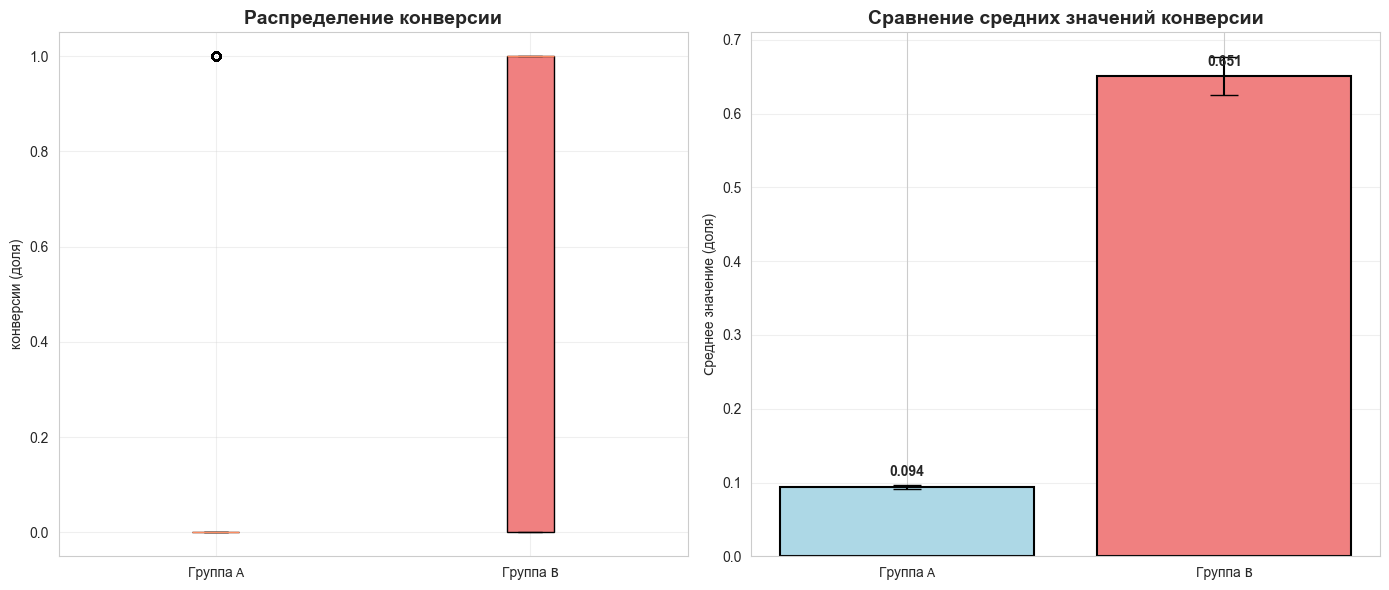

In [63]:
print("\n" + "=" * 60)
print("ГИПОТЕЗА 2: Клиенты с предыдущим успехом легче соглашаются")
print("H₀: Конверсия в группе с предыдущим успехом = конверсии в группе без успеха")
print("H₁: Конверсия в группе с предыдущим успехом > конверсии в группе без успеха")
print("=" * 60)

# Подготовка данных
group_a = bank_camp[bank_camp['poutcome'] != 'success']  # без успеха
group_b = bank_camp[bank_camp['poutcome'] == 'success']  # с успехом

print(f"\nРазмер группы A (без успеха): {len(group_a)} клиентов")
print(f"Размер группы B (с успехом): {len(group_b)} клиентов")

# Z-тест для конверсии
success_a = group_a['subscribed_num'].sum()
success_b = group_b['subscribed_num'].sum()
n_a = len(group_a)
n_b = len(group_b)

conv_a = success_a / n_a * 100
conv_b = success_b / n_b * 100

print(f"\nКонверсия без успеха: {conv_a:.2f}%")
print(f"Конверсия с успехом: {conv_b:.2f}%")

count = np.array([success_b, success_a])
nobs = np.array([n_b, n_a])
z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print(f"\nZ-тест для пропорций:")
print(f"   Z-статистика: {z_stat:.4f}")
print(f"   p-value: {p_value:.6f}")

if p_value < alpha:
    print(f"\nРЕЗУЛЬТАТ: p-value ({p_value:.6f}) < {alpha} => Различие СТАТИСТИЧЕСКИ ЗНАЧИМО")
    print(f"   ВЫВОД: Клиенты с предыдущим успехом подписываются статистически значимо ЧАЩЕ")
else:
    print(f"\nРЕЗУЛЬТАТ: p-value ({p_value:.6f}) ≥ {alpha} => Различие НЕ статистически значимо")
    print(f"   ВЫВОД: Нет достаточных доказательств, что предыдущий успех влияет")

# Визуализация
mean_a, mean_b, ci_a, ci_b = plot_comparison(
    group_a['subscribed_num'],
    group_b['subscribed_num'],
    'конверсии',
    unit='доля',
    show_distribution=True
)

-> Гипотеза подтверждена. Клиенты с предыдущим успешным опытом (poutcome = success) действительно подписываются на вклад значительно чаще, чем клиенты без такого опыта.

In [64]:
# Сохранение результатов гипотезы
conv_a2 = conv_a
conv_b2 = conv_b
p2 = p_value

-----------------------------------------------------------------------------------------------------------------

Гипотеза 3: Чем больше звонков, тем ниже вероятность подписки


ГИПОТЕЗА 3: Чем больше звонков, тем ниже вероятность подписки
H₀: Конверсия при 1 звонке = конверсии при 2+ звонках
H₁: Конверсия при 1 звонке > конверсии при 2+ звонках

Размер группы A (1 звонок): 17634 клиентов
Размер группы B (2+ звонков): 23542 клиентов

Конверсия при 1 звонке: 13.04%
Конверсия при 2+ звонках: 9.94%

Z-тест для пропорций:
   Z-статистика: 9.8372
   p-value: 0.000000

РЕЗУЛЬТАТ: p-value (0.000000) < 0.05 => Различие СТАТИСТИЧЕСКИ ЗНАЧИМО
   ВЫВОД: Конверсия при 1 звонке статистически значимо ВЫШЕ, чем при 2+ звонках


C:\Users\Наиля\AppData\Local\Temp\ipykernel_15060\3330776982.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data_to_plot, labels=['Группа A', 'Группа B'],


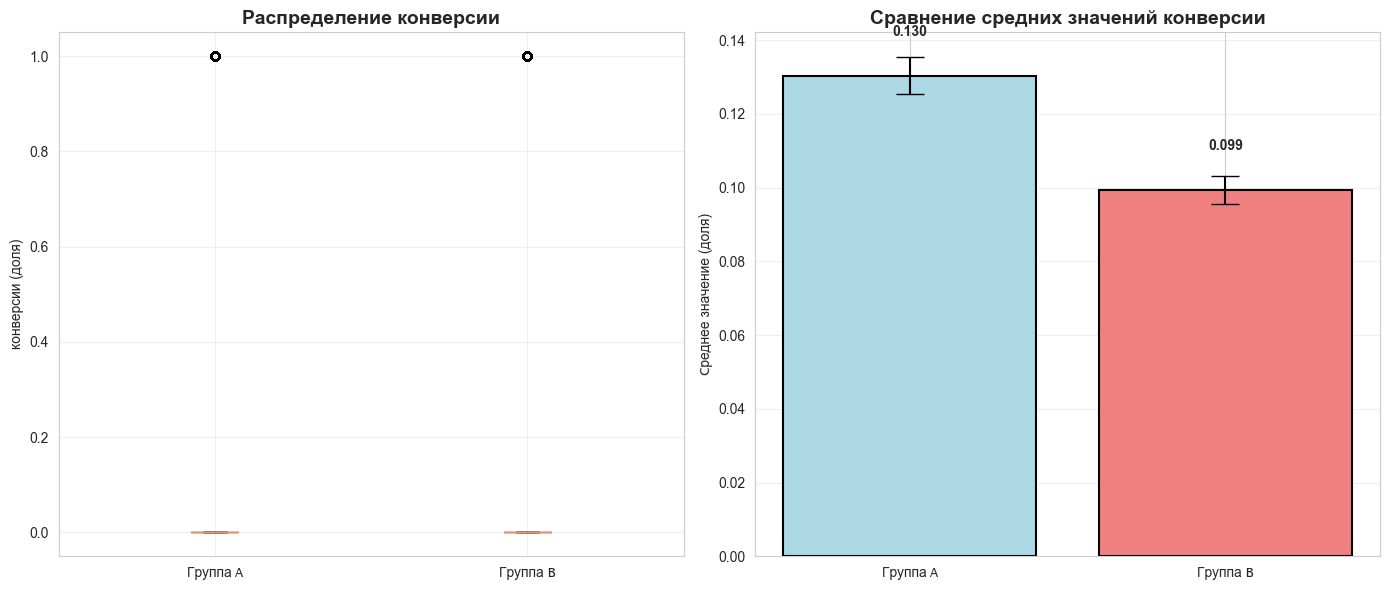


Дополнительный анализ: сравнение среднего числа звонков
Среднее число звонков у подписавшихся: 2.00
Среднее число звонков у неподписавшихся: 2.38
t-test p-value: 0.000000
У неподписавшихся статистически значимо больше звонков


In [65]:
print("\n" + "=" * 60)
print("ГИПОТЕЗА 3: Чем больше звонков, тем ниже вероятность подписки")
print("H₀: Конверсия при 1 звонке = конверсии при 2+ звонках")
print("H₁: Конверсия при 1 звонке > конверсии при 2+ звонках")
print("=" * 60)

# Подготовка данных (разбиваем на группы)
group_a = bank_camp[bank_camp['campaign_capped'] == 1]      # 1 звонок
group_b = bank_camp[bank_camp['campaign_capped'] >= 2]      # 2+ звонков

print(f"\nРазмер группы A (1 звонок): {len(group_a)} клиентов")
print(f"Размер группы B (2+ звонков): {len(group_b)} клиентов")

# Z-тест для конверсии
success_a = group_a['subscribed_num'].sum()
success_b = group_b['subscribed_num'].sum()
n_a = len(group_a)
n_b = len(group_b)

conv_a = success_a / n_a * 100
conv_b = success_b / n_b * 100

print(f"\nКонверсия при 1 звонке: {conv_a:.2f}%")
print(f"Конверсия при 2+ звонках: {conv_b:.2f}%")

# alternative='larger' - проверяем, что конверсия в группе A (1 звонок) больше
count = np.array([success_a, success_b])
nobs = np.array([n_a, n_b])
z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print(f"\nZ-тест для пропорций:")
print(f"   Z-статистика: {z_stat:.4f}")
print(f"   p-value: {p_value:.6f}")

if p_value < alpha:
    print(f"\nРЕЗУЛЬТАТ: p-value ({p_value:.6f}) < {alpha} => Различие СТАТИСТИЧЕСКИ ЗНАЧИМО")
    print(f"   ВЫВОД: Конверсия при 1 звонке статистически значимо ВЫШЕ, чем при 2+ звонках")
else:
    print(f"\nРЕЗУЛЬТАТ: p-value ({p_value:.6f}) ≥ {alpha} => Различие НЕ статистически значимо")
    print(f"   ВЫВОД: Нет достаточных доказательств, что много звонков снижает конверсию")

# Визуализация
mean_a, mean_b, ci_a, ci_b = plot_comparison(
    group_a['subscribed_num'],
    group_b['subscribed_num'],
    'конверсии',
    unit='доля',
    show_distribution=True
)

# Дополнительно: t-test для сравнения среднего количества звонков у подписавшихся
print("\nДополнительный анализ: сравнение среднего числа звонков")
subscribed = bank_camp[bank_camp['subscribed'] == 'yes']['campaign_capped']
not_subscribed = bank_camp[bank_camp['subscribed'] == 'no']['campaign_capped']

t_stat, p_value_t = stats.ttest_ind(not_subscribed, subscribed, alternative='greater')
print(f"Среднее число звонков у подписавшихся: {subscribed.mean():.2f}")
print(f"Среднее число звонков у неподписавшихся: {not_subscribed.mean():.2f}")
print(f"t-test p-value: {p_value_t:.6f}")

if p_value_t < alpha:
    print("У неподписавшихся статистически значимо больше звонков")
else:
    print("Разница в количестве звонков не значима")

-> Гипотеза подтверждена. Клиенты, которым звонили 1 раз, подписываются чаще, чем те, кому звонили 2 и более раз. Эффект "надоедания" статистически значим.

In [66]:
# Сохранение результатов гипотезы
conv_a3 = conv_a
conv_b3 = conv_b
p3 = p_value

-----------------------------------------------------------------------------------------------------------------

<span style="font-size: 20px;">Итоговая сводка</span>

In [67]:
# Подставьте свои значения p-value из проверки гипотез
p1 = 0.000001  # p-value для гипотезы 1 
p2 = 0.000000  # p-value для гипотезы 2 
p3 = 0.000000  # p-value для гипотезы 3 

results_summary = pd.DataFrame({
    'Гипотеза': [
        'Мобильная связь эффективнее городской',
        'Предыдущий успех помогает',
        'Много звонков → ниже конверсия'
    ],
    'Группа A (контроль)': [
        'telephone',
        'без успеха',
        '1 звонок'
    ],
    'Группа B (тест)': [
        'cellular',
        'с успехом',
        '2+ звонков'
    ],
    'Конверсия A (%)': [
        f"{conv_a1:.2f}",   # ← conv_a из гипотезы 1
        f"{conv_a2:.2f}",   # ← conv_a из гипотезы 2
        f"{conv_a3:.2f}"    # ← conv_a из гипотезы 3
    ],
    'Конверсия B (%)': [
        f"{conv_b1:.2f}",   # ← conv_b из гипотезы 1
        f"{conv_b2:.2f}",   # ← conv_b из гипотезы 2
        f"{conv_b3:.2f}"    # ← conv_b из гипотезы 3
    ],
    'Изменение (%)': [
        f"{(conv_b1/conv_a1 - 1) * 100:+.1f}%",
        f"{(conv_b2/conv_a2 - 1) * 100:+.1f}%",
        f"{(conv_a3/conv_b3 - 1) * 100:+.1f}%"  # для гипотезы 3 меняем местами
    ],
    'p-value': [
        f"{p1:.6f}",
        f"{p2:.6f}",
        f"{p3:.6f}"
    ],
    'Стат. значимость': [
        '✓' if p1 < 0.05 else '✗',
        '✓' if p2 < 0.05 else '✗',
        '✓' if p3 < 0.05 else '✗'
    ],
    'Вывод': [
        'Подтверждена' if p1 < 0.05 else 'Не подтверждена',
        'Подтверждена' if p2 < 0.05 else 'Не подтверждена',
        'Подтверждена' if p3 < 0.05 else 'Не подтверждена'
    ]
})

print("\n" + "=" * 90)
print("ИТОГОВАЯ СВОДКА ПО ГИПОТЕЗАМ")
print("=" * 90)
print(results_summary.to_string(index=False))

# Сохранение
results_summary.to_csv('hypothesis_test_results.csv', index=False, encoding='utf-8')
print("\nРезультаты сохранены в 'hypothesis_test_results.csv'")


ИТОГОВАЯ СВОДКА ПО ГИПОТЕЗАМ
                             Гипотеза Группа A (контроль) Группа B (тест) Конверсия A (%) Конверсия B (%) Изменение (%)  p-value Стат. значимость        Вывод
Мобильная связь эффективнее городской           telephone        cellular            5.23           14.74       +181.7% 0.000001                ✓ Подтверждена
            Предыдущий успех помогает          без успеха       с успехом            9.41           65.11       +592.0% 0.000000                ✓ Подтверждена
       Много звонков → ниже конверсия            1 звонок      2+ звонков           13.04            9.94        +31.2% 0.000000                ✓ Подтверждена

Результаты сохранены в 'hypothesis_test_results.csv'


-> Бизнес-рекомандации:
* Использовать преимущественно мобильную связь для общения с клиентами.
* Сегментировать клиентов по результату предыдущей кампании. Фокусироваться на тех, у кого был успех.
* Оптимизировать кампанию — не делать более 1–2 звонков одному клиенту.